# Credit Card Default Prediction

## YBI Foundation Data Science Internship

### Submitted By: Husna Ashraf

### Project Objective

The objective of this project is to develop a machine learning model that predicts whether a customer is likely to default on credit card payments based on financial and demographic information. The project uses data analysis, visualization, and machine learning techniques to identify patterns associated with default risk.

In [45]:
# Step 1 : import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Step 2 : import data
default = pd.read_csv('https://github.com/ybifoundation/Dataset/raw/main/Credit%20Default.csv')

In [25]:
default.head()

,Income,Age,Loan,Loan to Income,Default
0,66155.92510,59.017015,8106.532131,0.122537,0
1,34415.15397,48.117153,6564.745018,0.190752,0
2,57317.17006,63.108049,8020.953296,0.139940,0
3,42709.53420,45.751972,6103.642260,0.142911,0
4,66952.68885,18.584336,8770.099235,0.130990,1


In [26]:
default.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Income          2000 non-null   float64
 1   Age             2000 non-null   float64
 2   Loan            2000 non-null   float64
 3   Loan to Income  2000 non-null   float64
 4   Default         2000 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 78.3 KB


In [27]:
default.describe()

,Income,Age,Loan,Loan to Income,Default
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,45331.600018,40.927143,4444.369695,0.098403,0.141500
std,14326.327119,13.262450,3045.410024,0.057620,0.348624
min,20014.489470,18.055189,1.377630,0.000049,0.000000
25%,32796.459720,29.062492,1939.708847,0.047903,0.000000
50%,45789.117310,41.382673,3974.719418,0.099437,0.000000
75%,57791.281670,52.596993,6432.410625,0.147585,0.000000
max,69995.685580,63.971796,13766.051240,0.199938,1.000000


In [28]:
# Count of each category
default['Default'].value_counts()

,count
Default,
0,1717
1,283


In [29]:
# Step 3 : define target (y) and features (X)

In [30]:
default.columns

Index(['Income', 'Age', 'Loan', 'Loan to Income', 'Default'], dtype='object')

In [31]:
y = default['Default']

In [32]:
X = default.drop(['Default'],axis=1)

## Exploratory Data Analysis (EDA) and Visualization

### 1.Feature Correlation Analysis

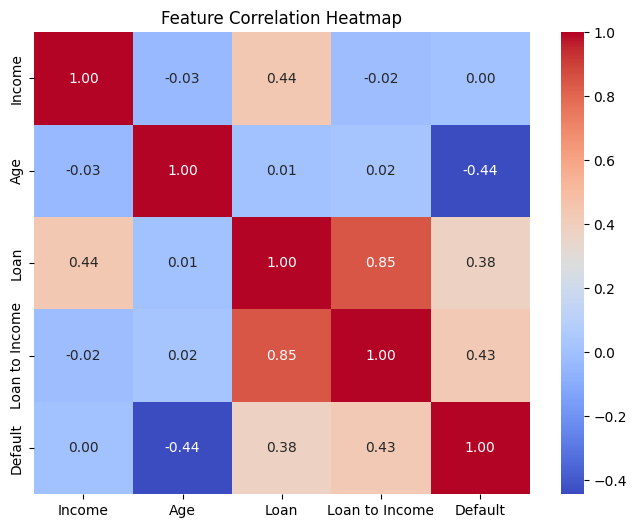

In [57]:
#relationships between variables

plt.figure(figsize=(8,6))
sns.heatmap(default.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

### 2. Distribution of Default and Non-Default Customers

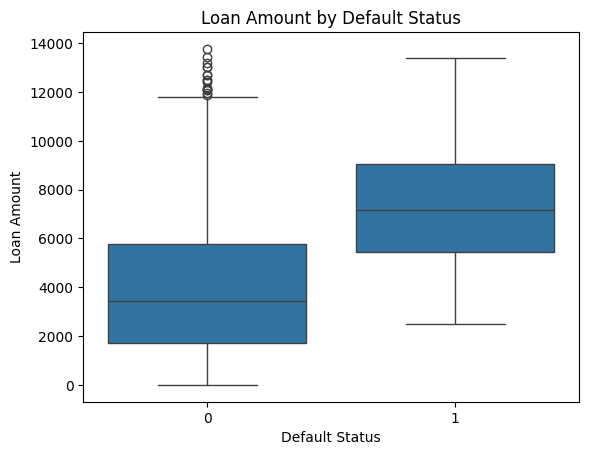

In [58]:
sns.boxplot(x='Default', y='Loan', data=default)
plt.xlabel('Default Status')
plt.ylabel('Loan Amount')
plt.title('Loan Amount by Default Status')
plt.show()

### 3. Loan Amount Distribution by Default Status

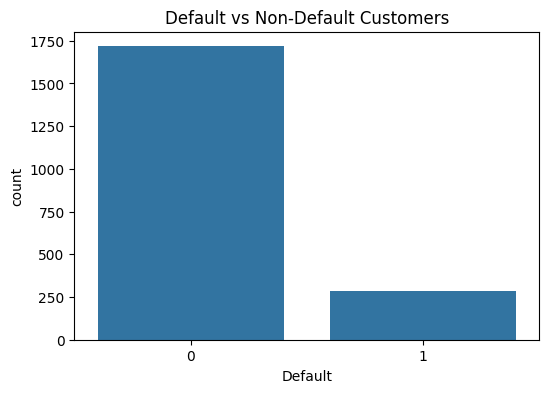

In [60]:
plt.figure(figsize=(6,4))
sns.countplot(x='Default', data=default)
plt.title('Default vs Non-Default Customers')
plt.show()

In [33]:
# Step 4 : train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size=0.7, random_state=2529)

In [34]:
# check shape of train and test sample
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1400, 4), (600, 4), (1400,), (600,))

In [35]:
# Step 5 : select model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [46]:
# Step 6 : train or fit model
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [37]:
model.intercept_

array([9.70585394])

In [38]:
model.coef_

array([[-2.38190492e-04, -3.47642263e-01,  1.72361397e-03,
         4.10940226e-01]])

In [39]:
# Step 7 : predict model
y_pred = model.predict(X_test)

In [40]:
y_pred

array([0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,

In [41]:
# Step 8 : model accuracy
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [42]:
confusion_matrix(y_test,y_pred)

array([[506,  13],
       [ 17,  64]])

In [43]:
accuracy_score(y_test,y_pred)

0.95

In [44]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       519
           1       0.83      0.79      0.81        81

    accuracy                           0.95       600
   macro avg       0.90      0.88      0.89       600
weighted avg       0.95      0.95      0.95       600



## Conclusion

In this project, a machine learning model was developed to predict credit card default risk using customer financial information. Exploratory Data Analysis (EDA) was performed using a correlation heatmap, count plot, and box plot to understand the relationships between variables and identify patterns associated with default behavior.

The model achieved an accuracy of approximately 95%, demonstrating strong predictive performance. The analysis indicated that factors such as loan amount, age, and loan-to-income ratio influence the likelihood of default. This project highlights how machine learning can help financial institutions identify high-risk customers and support better lending decisions.